# Fase 7 — Evaluación en Test

Evaluación completa del modelo GAF sobre el conjunto de test.
Todas las métricas se reportan en **espacio normalizado [-1, 1]**.

> **Nota normalización:** `normalize_series` usa `min_val=0` hardcodeado para todos los canales.
> Ventas y stock entran en espacio `log1p`; precio en espacio lineal.
> La diagonal de cada imagen GAF contiene la serie normalizada directamente.
> El dataset no expone `min_val`/`max_val` por ventana, por lo que no se desnormaliza aquí.

## 1 — Imports y setup

In [1]:
import sys
sys.path.append('/app')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

from config import (
    BATCH_SIZE, CHECKPOINTS, LOGS, FORECAST_HORIZON,
    LOSS_MSE_WEIGHT, LOSS_SSIM_WEIGHT, LOSS_CHANNEL_WEIGHTS,
    SEED,
)
from data.loader import load_and_prepare, COL_FECHA
from dataset.tf_dataset import build_tf_dataset_sampled
from model.autoencoder import build_autoencoder

print("GPU:", tf.config.list_physical_devices("GPU"))

2026-04-16 02:57:31.316623: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-16 02:57:31.316701: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-16 02:57:31.317662: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4070 Laptop GPU, compute capability 8.9
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2 — Funciones de loss y métricas

Idénticas a `train.py` para que `evaluate()` sea consistente.

In [2]:
_CHANNEL_WEIGHTS = tf.constant(LOSS_CHANNEL_WEIGHTS, dtype=tf.float32)

def ssim_loss(y_true, y_pred):
    y_true_f32 = tf.cast(y_true, tf.float32)
    y_pred_f32 = tf.cast(y_pred, tf.float32)
    y_true_01  = (y_true_f32 + 1.0) / 2.0
    y_pred_01  = (y_pred_f32 + 1.0) / 2.0
    ssim_per_channel = tf.stack([
        tf.image.ssim(
            y_true_01[..., c:c+1], y_pred_01[..., c:c+1],
            max_val=1.0, filter_size=3, filter_sigma=0.5, k1=0.01, k2=0.03,
        ) for c in range(3)
    ], axis=-1)
    ssim_mean = tf.reduce_mean(ssim_per_channel, axis=0)
    return 1.0 - tf.reduce_sum(ssim_mean * _CHANNEL_WEIGHTS)

def robust_diagonal_loss(y_true, y_pred):
    diag_true = tf.linalg.diag_part(tf.transpose(tf.cast(y_true, tf.float32), [0, 3, 1, 2]))
    diag_pred = tf.linalg.diag_part(tf.transpose(tf.cast(y_pred, tf.float32), [0, 3, 1, 2]))
    mae_per_channel = tf.reduce_mean(tf.abs(diag_true - diag_pred), axis=[0, 2])
    var_true = tf.math.reduce_variance(diag_true, axis=2)
    var_pred = tf.math.reduce_variance(diag_pred, axis=2)
    variance_loss_per_channel = tf.reduce_mean(tf.square(var_true - var_pred), axis=0)
    return tf.reduce_sum((mae_per_channel + variance_loss_per_channel) * _CHANNEL_WEIGHTS)

def combined_loss(y_true, y_pred):
    y_true_f32 = tf.cast(y_true, tf.float32)
    y_pred_f32 = tf.cast(y_pred, tf.float32)
    return (LOSS_MSE_WEIGHT  * robust_diagonal_loss(y_true_f32, y_pred_f32)
          + LOSS_SSIM_WEIGHT * ssim_loss(y_true_f32, y_pred_f32))

def ssim_metric(y_true, y_pred):
    y_true_01 = (tf.cast(y_true, tf.float32) + 1.0) / 2.0
    y_pred_01 = (tf.cast(y_pred, tf.float32) + 1.0) / 2.0
    return tf.reduce_mean(tf.image.ssim(
        y_true_01, y_pred_01,
        max_val=1.0, filter_size=3, filter_sigma=0.5, k1=0.01, k2=0.03,
    ))

def mae_diagonal_metric(y_true, y_pred):
    diag_true = tf.linalg.diag_part(tf.transpose(tf.cast(y_true, tf.float32), [0, 3, 1, 2]))
    diag_pred = tf.linalg.diag_part(tf.transpose(tf.cast(y_pred, tf.float32), [0, 3, 1, 2]))
    return tf.reduce_mean(tf.abs(diag_true - diag_pred))

print("✅ Funciones definidas")

✅ Funciones definidas


## 3 — Cargar datos y construir dataset de test

In [3]:
print("Cargando datos...")
train_df, val_df, test_df, local_map, product_map, valid_combos = load_and_prepare()
df_full   = pd.concat([train_df, val_df, test_df])
train_end = train_df[COL_FECHA].max()
val_end   = val_df[COL_FECHA].max()

print(f"  Train: hasta {train_end}")
print(f"  Val:   hasta {val_end}")
print(f"  Test:  {test_df[COL_FECHA].min()} → {test_df[COL_FECHA].max()}")
print(f"  Combinaciones válidas totales: {len(valid_combos)}")

# Usamos todas las combinaciones disponibles para test
N_COMBOS_TEST = 3000 # len(valid_combos)

test_ds = build_tf_dataset_sampled(
    df_full, local_map, product_map, valid_combos,
    split="test",
    train_end_date=train_end,
    val_end_date=val_end,
    batch_size=BATCH_SIZE,
    shuffle=False,
    n_combos=N_COMBOS_TEST,
    seed=SEED,
)
print(f"\nDataset test construido ({N_COMBOS_TEST} combinaciones)")

Cargando datos...
Cargando datos...
  Raw: 6,062,390 filas
Imputando...
  Después de imputación: 6,015,333 filas
Split temporal...
  Train: 4,138,281 filas | 2024-03-11 → 2025-08-07
  Val:   930,250 filas | 2025-08-08 → 2025-11-25
  Test:  946,802 filas | 2025-11-26 → 2026-03-15
Construyendo mappings...
  Locales:   1029
  Productos: 179
Filtrando combinaciones válidas...
  Combinaciones con >= 104 días: 12,358
  Train: hasta 2025-08-07 00:00:00
  Val:   hasta 2025-11-25 00:00:00
  Test:  2025-11-26 00:00:00 → 2026-03-15 00:00:00
  Combinaciones válidas totales: 12358
  Ventanas indexadas (test): 13,224 (168 con quiebre de stock, 13,056 sin quiebre)

Dataset test construido (3000 combinaciones)


## 4 — Cargar modelo

Prioridad: `phase2_best` → `phase1_best`.

In [4]:
autoencoder, encoder, decoder, emb_model = build_autoencoder(encoder_trainable=False)

ckpt_f2 = CHECKPOINTS / "phase2_best.weights.h5"
ckpt_f1 = CHECKPOINTS / "phase1_best.weights.h5"

if ckpt_f2.exists():
    autoencoder.load_weights(str(ckpt_f2), skip_mismatch=True)
    checkpoint_used = "phase2_best"
    print("✅ Pesos cargados: phase2_best.weights.h5")
else:
    autoencoder.load_weights(str(ckpt_f1), skip_mismatch=True)
    checkpoint_used = "phase1_best"
    print("⚠️  F2 no encontrado — usando phase1_best.weights.h5")

autoencoder.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=[ssim_metric, mae_diagonal_metric],
)

✅ Pesos cargados: phase2_best.weights.h5


## 5 — Métricas globales en test (`evaluate`)

In [5]:
print("Evaluando en test completo...")
results = autoencoder.evaluate(test_ds, verbose=1)

print("\n── Métricas globales TEST ─────────────────────────────")
print(f"  Loss (combined):       {results[0]:.4f}")
print(f"  SSIM (sin pesos):      {results[1]:.4f}")
print(f"  MAE diagonal (medio):  {results[2]:.4f}")
print(f"  Checkpoint:            {checkpoint_used}")

Evaluando en test completo...
827/827 [==============================] - 22s 21ms/step - loss: 0.3109 - ssim_metric: 0.6669 - mae_diagonal_metric: 0.2200

── Métricas globales TEST ─────────────────────────────
  Loss (combined):       0.3109
  SSIM (sin pesos):      0.6669
  MAE diagonal (medio):  0.2200
  Checkpoint:            phase2_best


## 6 — Recolectar predicciones

Recorre el dataset una vez y acumula todo en RAM.
Si hay OOM, reduce `N_COMBOS_TEST` en la celda 3.

In [6]:
all_inputs  = []
all_targets = []
all_preds   = []

print("Recolectando predicciones...")
for batch_inputs, batch_targets in test_ds:
    batch_preds = autoencoder(batch_inputs, training=False)
    all_inputs.append(batch_inputs["gaf_input"].numpy())
    all_targets.append(batch_targets.numpy())
    all_preds.append(batch_preds.numpy())

all_inputs  = np.concatenate(all_inputs,  axis=0).astype(np.float32)
all_targets = np.concatenate(all_targets, axis=0).astype(np.float32)
all_preds   = np.concatenate(all_preds,   axis=0).astype(np.float32)

print(f"  inputs  : {all_inputs.shape}")
print(f"  targets : {all_targets.shape}")
print(f"  preds   : {all_preds.shape}")

Recolectando predicciones...
  inputs  : (13224, 90, 90, 3)
  targets : (13224, 14, 14, 3)
  preds   : (13224, 14, 14, 3)


## 7 — MAE diagonal por canal y distribución SSIM

La diagonal de cada imagen GAF 7×7 contiene la serie normalizada directamente
(`np.fill_diagonal(hybrid, series_norm)` en `transform.py`).

| Canal | Rango | -1.0 significa |
|-------|-------|----------------|
| Ventas | [-1, 1] | 0 unidades (log1p, min=0) |
| Stock  | [-1, 1] | 0 unidades (log1p, min=0) |
| Precio | [-1, 1] | precio mínimo de la ventana |

── MAE diagonal por canal (espacio normalizado) ───────
  Ventas (log1p, norm)     : 0.5218
  Stock (log1p, norm)      : 0.1091
  Precio (norm)            : 0.0298

Calculando SSIM por muestra...

── SSIM por muestra ───────────────────────────────────
  Media:   0.6669
  Mediana: 0.6751
  Std:     0.1512
  P10:     0.4667
  P90:     0.8652


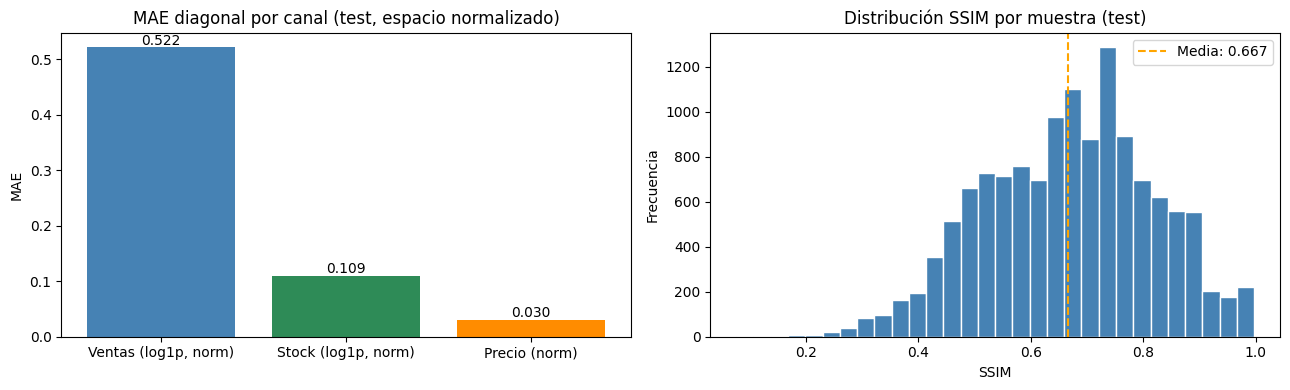

In [7]:
# Extraer diagonales: (N, 3, 7)
diag_true = np.diagonal(
    np.transpose(all_targets, (0, 3, 1, 2)),  # → (N, 3, 7, 7)
    axis1=-2, axis2=-1
)  # → (N, 3, 7)

diag_pred = np.diagonal(
    np.transpose(all_preds, (0, 3, 1, 2)),
    axis1=-2, axis2=-1
)  # → (N, 3, 7)

canal_names = ["Ventas (log1p, norm)", "Stock (log1p, norm)", "Precio (norm)"]

# MAE por canal: promedio sobre muestras y días
mae_por_canal = np.mean(np.abs(diag_true - diag_pred), axis=(0, 2))  # (3,)

print("── MAE diagonal por canal (espacio normalizado) ───────")
for name, mae in zip(canal_names, mae_por_canal):
    print(f"  {name:25s}: {mae:.4f}")

# SSIM por muestra
print("\nCalculando SSIM por muestra...")
ssim_per_sample = []
for i in range(len(all_targets)):
    t = (all_targets[i:i+1] + 1.0) / 2.0
    p = (all_preds[i:i+1]   + 1.0) / 2.0
    s = tf.image.ssim(t, p, max_val=1.0, filter_size=3, filter_sigma=0.5,
                      k1=0.01, k2=0.03).numpy()
    ssim_per_sample.append(float(np.mean(s)))
ssim_per_sample = np.array(ssim_per_sample)

print(f"\n── SSIM por muestra ───────────────────────────────────")
print(f"  Media:   {ssim_per_sample.mean():.4f}")
print(f"  Mediana: {np.median(ssim_per_sample):.4f}")
print(f"  Std:     {ssim_per_sample.std():.4f}")
print(f"  P10:     {np.percentile(ssim_per_sample, 10):.4f}")
print(f"  P90:     {np.percentile(ssim_per_sample, 90):.4f}")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ["steelblue", "seagreen", "darkorange"]
axes[0].bar(canal_names, mae_por_canal, color=colors)
axes[0].set_title("MAE diagonal por canal (test, espacio normalizado)")
axes[0].set_ylabel("MAE")
for i, v in enumerate(mae_por_canal):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)

axes[1].hist(ssim_per_sample, bins=30, color="steelblue", edgecolor="white")
axes[1].axvline(ssim_per_sample.mean(), color="orange", linestyle="--",
                label=f"Media: {ssim_per_sample.mean():.3f}")
axes[1].set_title("Distribución SSIM por muestra (test)")
axes[1].set_xlabel("SSIM"); axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.tight_layout()
plt.savefig("/app/outputs/visualizations/test_metricas_globales.png", dpi=120, bbox_inches="tight")
plt.show()

## 8 — Segmentación: quiebre vs demanda normal

Umbral `-0.8` en espacio normalizado: con `min_val=0` y `log1p`, el valor real `0` mapea a `-1.0`.
Un umbral de `-0.8` captura días con ventas o stock muy bajos (cercanos a cero).
Ajusta a `-0.99` si quieres únicamente zeros exactos.

In [8]:
# ── Máscaras separadas por canal (stock es el objetivo principal) ────────────
UMBRAL_QUIEBRE_VENTAS = -0.8   # captura días con ventas muy bajas
UMBRAL_QUIEBRE_STOCK  = -0.8   # captura días con stock muy bajo (quiebre real)

diag_ventas_true = diag_true[:, 0, :]  # (N, 14)
diag_stock_true  = diag_true[:, 1, :]  # (N, 14)

# Máscaras independientes por canal
mask_quiebre_ventas = (diag_ventas_true < UMBRAL_QUIEBRE_VENTAS).any(axis=1)
mask_quiebre_stock  = (diag_stock_true  < UMBRAL_QUIEBRE_STOCK).any(axis=1)

# Máscara combinada (para compatibilidad con celdas anteriores)
mask_quiebre = mask_quiebre_ventas | mask_quiebre_stock
mask_normal  = ~mask_quiebre

print(f'Umbral ventas: {UMBRAL_QUIEBRE_VENTAS}  |  Umbral stock: {UMBRAL_QUIEBRE_STOCK}')
print(f'  Quiebre ventas  : {mask_quiebre_ventas.sum():,} ({100*mask_quiebre_ventas.mean():.1f}%)')
print(f'  Quiebre stock   : {mask_quiebre_stock.sum():,} ({100*mask_quiebre_stock.mean():.1f}%)')
print(f'  Quiebre (union) : {mask_quiebre.sum():,} ({100*mask_quiebre.mean():.1f}%)')
print(f'  Normal          : {mask_normal.sum():,} ({100*mask_normal.mean():.1f}%)')

for seg_name, mask in [("Quiebre ventas", mask_quiebre_ventas),
                        ("Quiebre stock",  mask_quiebre_stock),
                        ("Normal",         mask_normal)]:
    if mask.sum() == 0:
        print(f'\n{seg_name}: sin muestras')
        continue
    mae_seg  = np.mean(np.abs(diag_true[mask] - diag_pred[mask]), axis=(0, 2))
    ssim_seg = ssim_per_sample[mask].mean()
    print(f'\n── {seg_name} (n={mask.sum():,}) ─────────────────────────')
    for name, mae in zip(canal_names, mae_seg):
        print(f'  MAE {name:25s}: {mae:.4f}')
    print(f'  SSIM medio: {ssim_seg:.4f}')


Umbral ventas: -0.8  |  Umbral stock: -0.8
  Quiebre ventas  : 10,843 (82.0%)
  Quiebre stock   : 116 (0.9%)
  Quiebre (union) : 10,850 (82.0%)
  Normal          : 2,374 (18.0%)

── Quiebre ventas (n=10,843) ─────────────────────────
  MAE Ventas (log1p, norm)     : 0.4981
  MAE Stock (log1p, norm)      : 0.1136
  MAE Precio (norm)            : 0.0241
  SSIM medio: 0.6513

── Quiebre stock (n=116) ─────────────────────────
  MAE Ventas (log1p, norm)     : 0.5552
  MAE Stock (log1p, norm)      : 0.6424
  MAE Precio (norm)            : 0.1278
  SSIM medio: 0.4215

── Normal (n=2,374) ─────────────────────────
  MAE Ventas (log1p, norm)     : 0.6301
  MAE Stock (log1p, norm)      : 0.0875
  MAE Precio (norm)            : 0.0559
  SSIM medio: 0.7390


## 9 — Detección de quiebres: precisión / recall

El modelo «detecta quiebre» si su predicción tiene algún día de ventas o stock por debajo del mismo umbral.

── Detección de quiebres (umbral ventas=-0.8, stock=-0.8) ──
  TP=9,493  FP=1,611  FN=1,357  TN=763
  Precisión: 0.855
  Recall:    0.875
  F1:        0.865


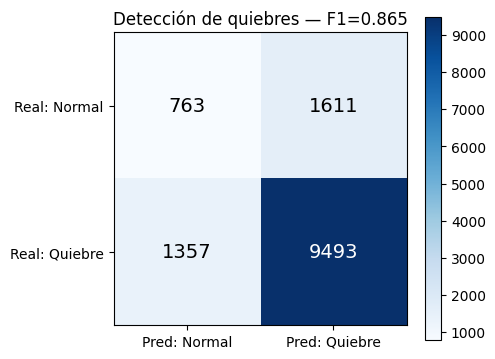

In [9]:
pred_diag_ventas = diag_pred[:, 0, :]
pred_diag_stock  = diag_pred[:, 1, :]

pred_quiebre = (
    (pred_diag_ventas < UMBRAL_QUIEBRE_VENTAS).any(axis=1) |
    (pred_diag_stock  < UMBRAL_QUIEBRE_STOCK).any(axis=1)
)

tp = int((mask_quiebre &  pred_quiebre).sum())
fp = int((~mask_quiebre & pred_quiebre).sum())
fn = int((mask_quiebre & ~pred_quiebre).sum())
tn = int((~mask_quiebre & ~pred_quiebre).sum())

precision = tp / (tp + fp + 1e-9)
recall    = tp / (tp + fn + 1e-9)
f1        = 2 * precision * recall / (precision + recall + 1e-9)

print(f'── Detección de quiebres (umbral ventas={UMBRAL_QUIEBRE_VENTAS}, stock={UMBRAL_QUIEBRE_STOCK}) ──')
print(f"  TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")
print(f"  Precisión: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  F1:        {f1:.3f}")

# Matriz de confusión visual
fig, ax = plt.subplots(figsize=(5, 4))
cm = np.array([[tn, fp], [fn, tp]])
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred: Normal", "Pred: Quiebre"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Real: Normal", "Real: Quiebre"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > cm.max() * 0.6 else "black")
ax.set_title(f"Detección de quiebres — F1={f1:.3f}")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("/app/outputs/visualizations/test_confusion_quiebres.png", dpi=120, bbox_inches="tight")
plt.show()

## 10 — Visualización GAF 7×7: Target | Predicción | |Diferencia|

Muestra balanceada: mitad quiebres, mitad normales.

Sample GAF: 4 quiebres stock + 2 quiebres ventas + 2 normales


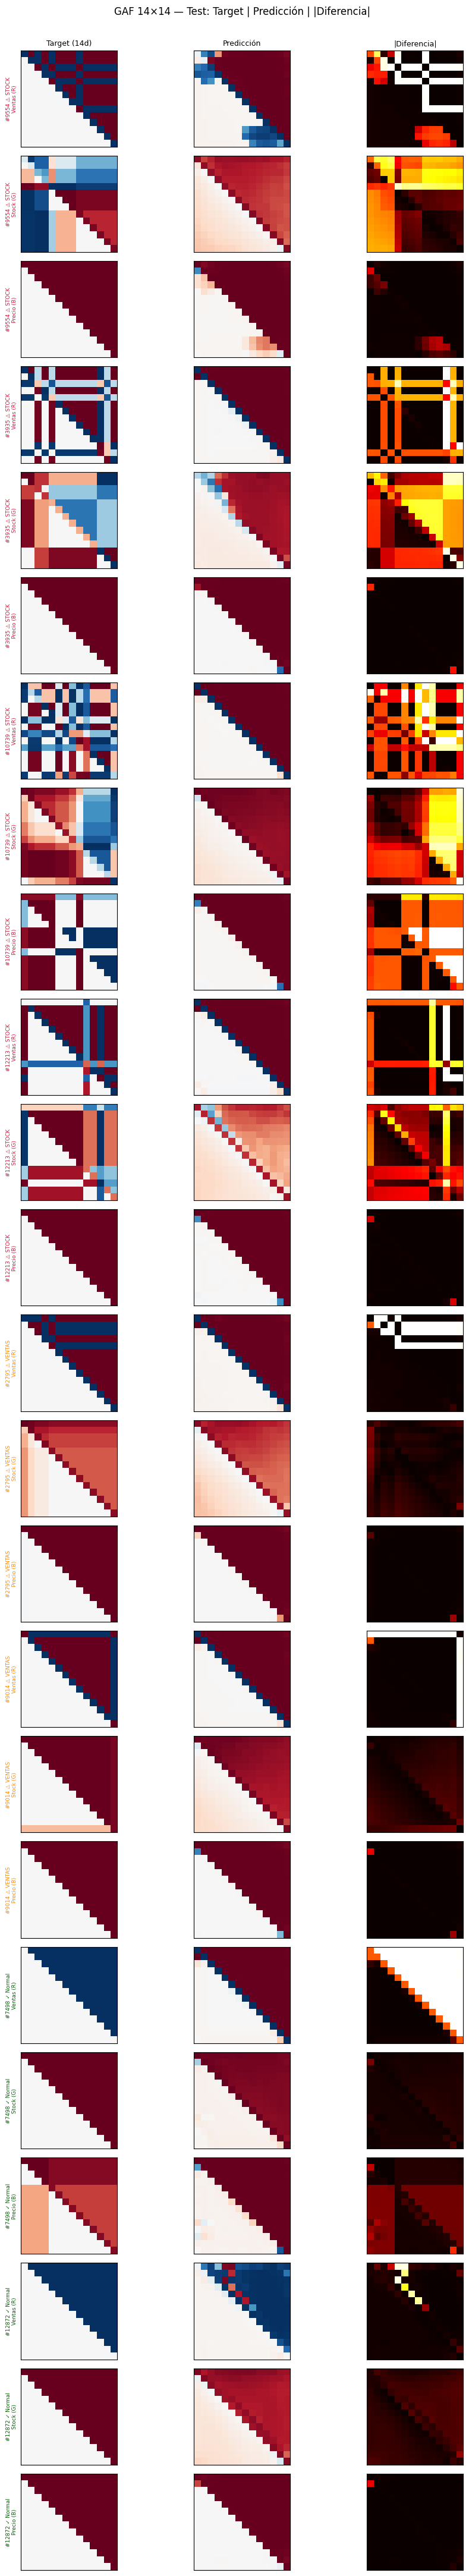

In [10]:
# ── Visualización GAF balanceada con quiebres de STOCK garantizados ──────────
N_VIZ = 8
rng = np.random.default_rng(42)

# Priorizar quiebres de stock (objetivo principal)
idx_quiebre_stock  = np.where(mask_quiebre_stock)[0]
idx_quiebre_ventas = np.where(mask_quiebre_ventas & ~mask_quiebre_stock)[0]  # solo ventas
idx_normal         = np.where(mask_normal)[0]

n_stock  = min(N_VIZ // 2, len(idx_quiebre_stock))
n_ventas = min(N_VIZ // 4, len(idx_quiebre_ventas))
n_normal = min(N_VIZ - n_stock - n_ventas, len(idx_normal))

selected = np.concatenate([
    rng.choice(idx_quiebre_stock,  n_stock,  replace=False) if n_stock  > 0 else np.array([], dtype=int),
    rng.choice(idx_quiebre_ventas, n_ventas, replace=False) if n_ventas > 0 else np.array([], dtype=int),
    rng.choice(idx_normal,         n_normal, replace=False) if n_normal > 0 else np.array([], dtype=int),
]).astype(int)

print(f'Sample GAF: {n_stock} quiebres stock + {n_ventas} quiebres ventas + {n_normal} normales')

canal_labels = ['Ventas (R)', 'Stock (G)', 'Precio (B)']

def to_01(img):
    return np.clip((img + 1.0) / 2.0, 0.0, 1.0)

n_rows = len(selected) * 3
fig, axes = plt.subplots(n_rows, 3, figsize=(10, n_rows * 1.8))
fig.suptitle(f'GAF {FORECAST_HORIZON}×{FORECAST_HORIZON} — Test: Target | Predicción | |Diferencia|', fontsize=12, y=1.002)

for col, title in enumerate([f'Target ({FORECAST_HORIZON}d)', 'Predicción', '|Diferencia|']):
    axes[0, col].set_title(title, fontsize=9)

for row_base, idx in enumerate(selected):
    tgt_img  = all_targets[idx]
    pred_img = all_preds[idx]
    diff_img = np.abs(tgt_img - pred_img)
    es_stock  = mask_quiebre_stock[idx]
    es_ventas = mask_quiebre_ventas[idx] and not es_stock

    if es_stock:
        label_str, color_str = '⚠ STOCK',   'crimson'
    elif es_ventas:
        label_str, color_str = '⚠ VENTAS',  'darkorange'
    else:
        label_str, color_str = '✓ Normal',  'darkgreen'

    for c, canal_label in enumerate(canal_labels):
        row = row_base * 3 + c
        axes[row, 0].imshow(to_01(tgt_img[..., c]),  cmap='RdBu_r', vmin=0, vmax=1)
        axes[row, 1].imshow(to_01(pred_img[..., c]), cmap='RdBu_r', vmin=0, vmax=1)
        axes[row, 2].imshow(diff_img[..., c],        cmap='hot',    vmin=0, vmax=2)
        axes[row, 0].set_ylabel(f'#{idx} {label_str}\n{canal_label}',
                                fontsize=6.5, color=color_str)
        for ax in axes[row]:
            ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('/app/outputs/visualizations/test_gaf_visualizacion.png', dpi=110, bbox_inches='tight')
plt.show()


## 11 — Diagonal: 7 días predichos vs reales (espacio normalizado)

Línea punteada en `y=-1.0` = cero real para ventas/stock. Línea en `y=0.0` = referencia.

Diagonal sample: 3 stock + 1 ventas + 2 normales


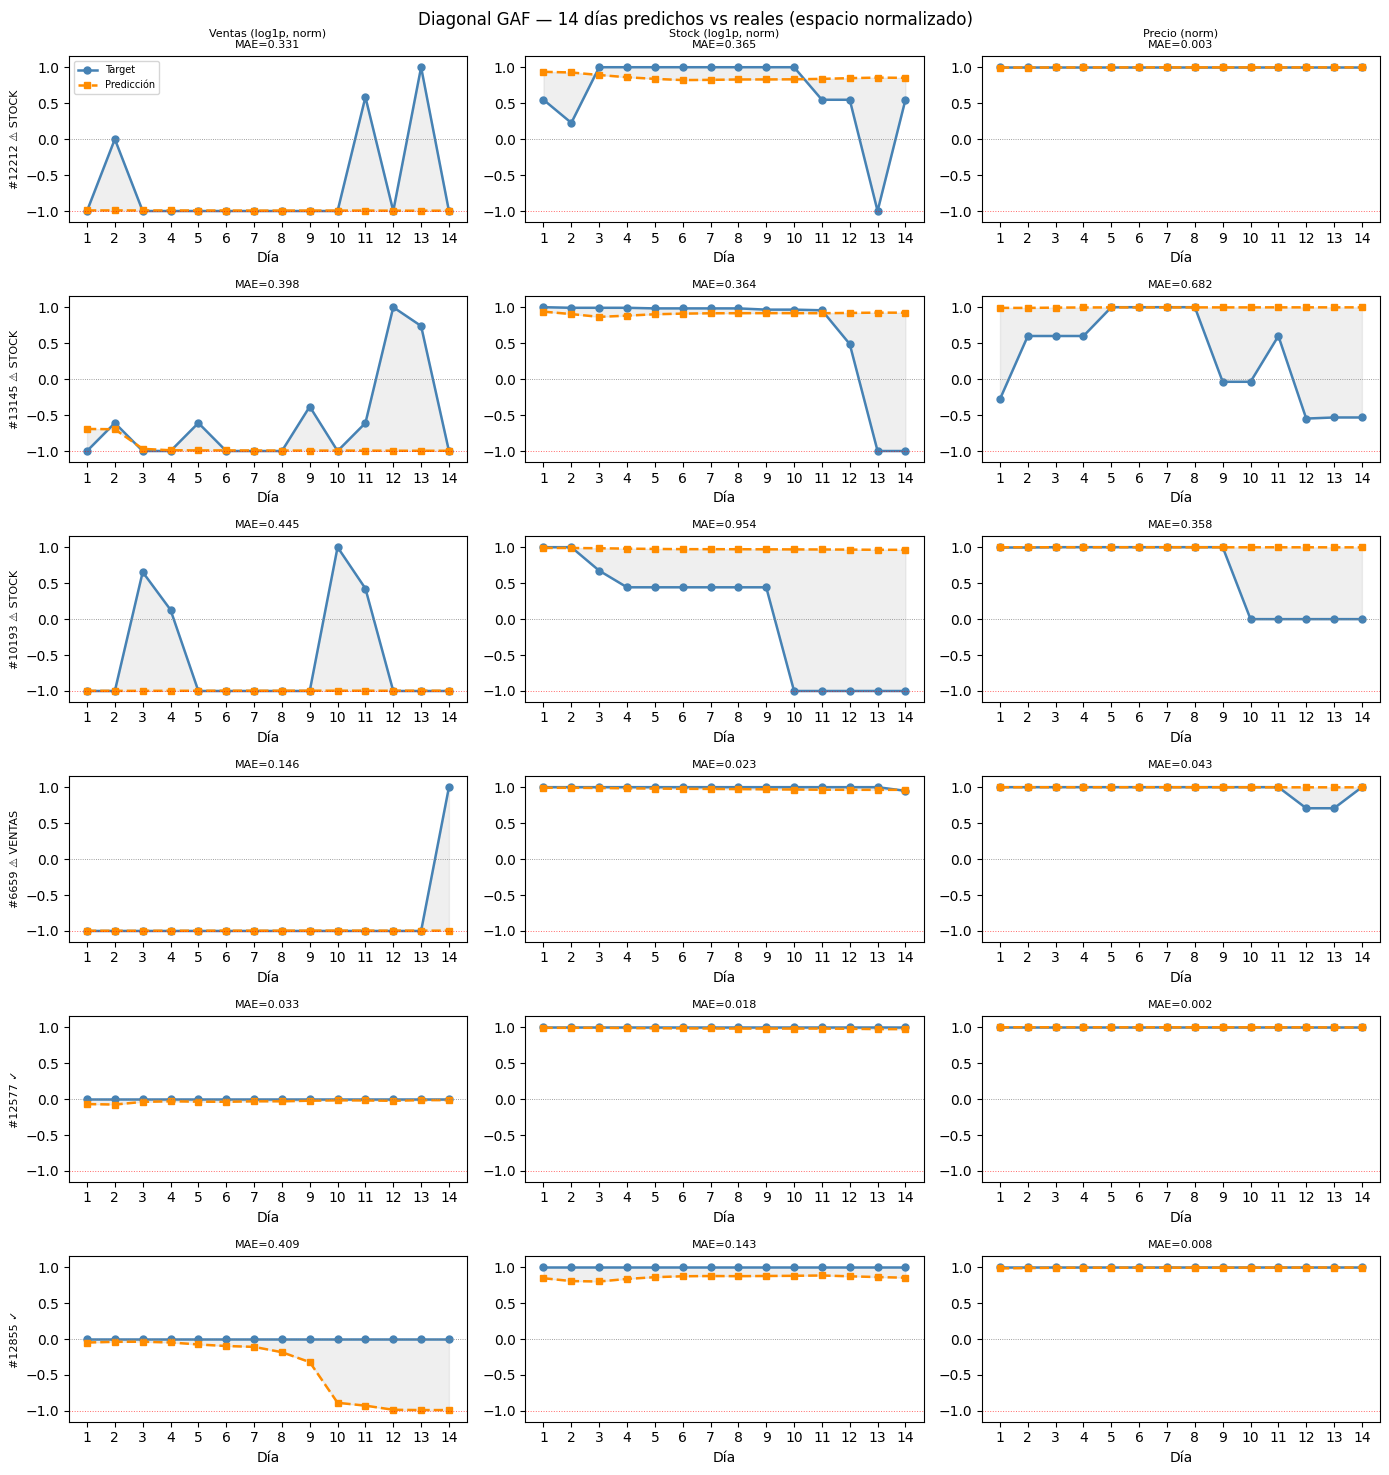

In [11]:
# ── Diagonal: muestras priorizando quiebres de stock ─────────────────────────
N_DIAG = 6
rng2 = np.random.default_rng(99)

idx_q_stock  = np.where(mask_quiebre_stock)[0]
idx_q_ventas = np.where(mask_quiebre_ventas & ~mask_quiebre_stock)[0]
idx_norm     = np.where(mask_normal)[0]

n_s = min(3, len(idx_q_stock))
n_v = min(1, len(idx_q_ventas))
n_n = min(N_DIAG - n_s - n_v, len(idx_norm))

idx_diag = np.concatenate([
    rng2.choice(idx_q_stock,  n_s, replace=False) if n_s > 0 else np.array([], dtype=int),
    rng2.choice(idx_q_ventas, n_v, replace=False) if n_v > 0 else np.array([], dtype=int),
    rng2.choice(idx_norm,     n_n, replace=False) if n_n > 0 else np.array([], dtype=int),
]).astype(int)

print(f'Diagonal sample: {n_s} stock + {n_v} ventas + {n_n} normales')

colores_canal = ['steelblue', 'seagreen', 'darkorange']
dias = np.arange(1, FORECAST_HORIZON + 1)

fig, axes = plt.subplots(len(idx_diag), 3, figsize=(14, len(idx_diag) * 2.5))
fig.suptitle(f'Diagonal GAF — {FORECAST_HORIZON} días predichos vs reales (espacio normalizado)', fontsize=12)

for row, idx in enumerate(idx_diag):
    es_stock  = mask_quiebre_stock[idx]
    es_ventas = mask_quiebre_ventas[idx] and not es_stock
    if es_stock:
        label_str = '⚠ STOCK'
    elif es_ventas:
        label_str = '⚠ VENTAS'
    else:
        label_str = '✓'

    for c, (canal_label, color) in enumerate(zip(canal_names, colores_canal)):
        ax = axes[row, c]
        t_vals  = diag_true[idx, c, :]
        p_vals  = diag_pred[idx, c, :]
        mae_val = np.mean(np.abs(t_vals - p_vals))

        ax.fill_between(dias, t_vals, p_vals, alpha=0.12, color='gray')
        ax.plot(dias, t_vals, 'o-',  label='Target',     color='steelblue',  lw=1.8, ms=5)
        ax.plot(dias, p_vals, 's--', label='Predicción', color='darkorange', lw=1.8, ms=5)
        ax.axhline(-1.0, color='red',  lw=0.7, linestyle=':', alpha=0.6)
        ax.axhline( 0.0, color='gray', lw=0.6, linestyle=':')
        ax.set_ylim(-1.15, 1.15)
        ax.set_xticks(dias)
        ax.set_xlabel('Día')

        if c == 0:
            ax.set_ylabel(f'#{idx} {label_str}', fontsize=8)
        ax.set_title(f'{canal_label}\nMAE={mae_val:.3f}' if row == 0 else f'MAE={mae_val:.3f}', fontsize=8)
        if row == 0 and c == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('/app/outputs/visualizations/test_diagonal_norm.png', dpi=120, bbox_inches='tight')
plt.show()


Sample balanceado: 116 quiebres stock + 116 quiebres ventas + 464 normales = 696 total


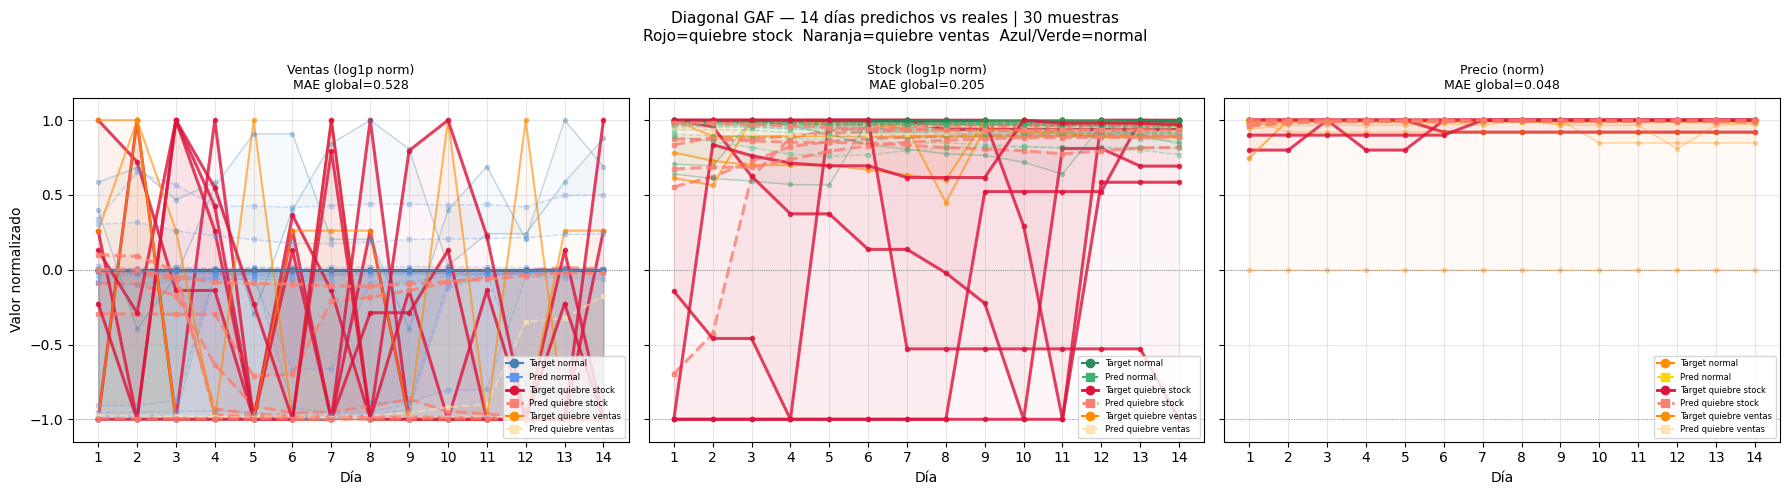

Guardado en /app/outputs/visualizations/test_diagonal_por_canal.png


In [12]:
def plot_diagonal_por_canal_test(diag_true, diag_pred,
                                  mask_quiebre_stock, mask_quiebre_ventas,
                                  selected, canal_names=None, n_samples=None):
    if canal_names is None:
        canal_names = ['Ventas (log1p norm)', 'Stock (log1p norm)', 'Precio (norm)']

    colores_target  = ['steelblue',      'seagreen',      'darkorange']
    colores_pred    = ['cornflowerblue', 'mediumseagreen', 'gold']

    n_samples = min(n_samples or len(selected), len(selected))
    idx_plot  = selected[:n_samples]
    dias      = np.arange(1, FORECAST_HORIZON + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(
        f'Diagonal GAF — {FORECAST_HORIZON} días predichos vs reales | {n_samples} muestras\n'
        f'Rojo=quiebre stock  Naranja=quiebre ventas  Azul/Verde=normal',
        fontsize=11
    )

    for c, (ax, canal_label) in enumerate(zip(axes, canal_names)):
        maes = []
        for idx in idx_plot:
            es_stock  = mask_quiebre_stock[idx]
            es_ventas = mask_quiebre_ventas[idx] and not es_stock

            t_vals = diag_true[idx, c, :]
            p_vals = diag_pred[idx, c, :]
            maes.append(np.mean(np.abs(t_vals - p_vals)))

            if es_stock:
                ct, cp, alpha, lw = 'crimson',    'salmon',      0.8, 2.2
            elif es_ventas:
                ct, cp, alpha, lw = 'darkorange', 'moccasin',    0.6, 1.5
            else:
                ct, cp, alpha, lw = colores_target[c], colores_pred[c], 0.3, 1.0

            ax.plot(dias, t_vals, 'o-',  color=ct, lw=lw, ms=3, alpha=alpha)
            ax.plot(dias, p_vals, 's--', color=cp, lw=lw, ms=3, alpha=alpha)
            ax.fill_between(dias, t_vals, p_vals, alpha=0.04, color=ct)

        mae_global = np.mean(maes)
        ax.axhline(-1.0, color='red',  lw=0.7, linestyle=':', alpha=0.5)
        ax.axhline( 0.0, color='gray', lw=0.6, linestyle=':')
        ax.set_ylim(-1.15, 1.15)
        ax.set_xticks(dias)
        ax.set_xlabel('Día')
        ax.set_title(f'{canal_label}\nMAE global={mae_global:.3f}', fontsize=9)
        ax.grid(alpha=0.3)

        from matplotlib.lines import Line2D
        handles = [
            Line2D([0],[0], color=colores_target[c], lw=1.5, marker='o', label='Target normal'),
            Line2D([0],[0], color=colores_pred[c],   lw=1.5, marker='s', linestyle='--', label='Pred normal'),
            Line2D([0],[0], color='crimson',         lw=2.0, marker='o', label='Target quiebre stock'),
            Line2D([0],[0], color='salmon',          lw=2.0, marker='s', linestyle='--', label='Pred quiebre stock'),
            Line2D([0],[0], color='darkorange',      lw=1.5, marker='o', label='Target quiebre ventas'),
            Line2D([0],[0], color='moccasin',        lw=1.5, marker='s', linestyle='--', label='Pred quiebre ventas'),
        ]
        ax.legend(handles=handles, fontsize=6, loc='lower right')

    axes[0].set_ylabel('Valor normalizado')
    plt.tight_layout()
    path = '/app/outputs/visualizations/test_diagonal_por_canal.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Guardado en {path}')


# ── Sample garantizando todos los quiebres de stock disponibles ───────────────
rng3 = np.random.default_rng(42)

idx_q_stock  = np.where(mask_quiebre_stock)[0]
idx_q_ventas = np.where(mask_quiebre_ventas & ~mask_quiebre_stock)[0]
idx_norm     = np.where(mask_normal)[0]

# Todos los quiebres de stock + ratio 1:4 de normales
n_stock  = len(idx_q_stock)
n_ventas = min(n_stock, len(idx_q_ventas))          # igual cantidad que stock
n_normal = min(n_stock * 4, len(idx_norm))           # 4x normales

selected_bal = np.concatenate([
    idx_q_stock,
    rng3.choice(idx_q_ventas, n_ventas, replace=False) if n_ventas > 0 else np.array([], dtype=int),
    rng3.choice(idx_norm,     n_normal, replace=False) if n_normal > 0 else np.array([], dtype=int),
]).astype(int)
rng3.shuffle(selected_bal)

print(f'Sample balanceado: {n_stock} quiebres stock + {n_ventas} quiebres ventas + {n_normal} normales = {len(selected_bal)} total')

plot_diagonal_por_canal_test(
    diag_true, diag_pred,
    mask_quiebre_stock, mask_quiebre_ventas,
    selected=selected_bal,
    n_samples=30#len(selected_bal),
)


## 12 — Resumen ejecutivo

In [13]:
print("═" * 55)
print("  RESUMEN EVALUACIÓN TEST")
print("═" * 55)
print(f"  Checkpoint:            {checkpoint_used}")
print(f"  Muestras evaluadas:    {len(all_targets):,}")
print(f"  Umbral ventas (norm):  {UMBRAL_QUIEBRE_VENTAS}")
print(f"  Umbral stock  (norm):  {UMBRAL_QUIEBRE_STOCK}")
print()
print(f"  SSIM medio:    {ssim_per_sample.mean():.4f}")
print(f"  SSIM mediana:  {np.median(ssim_per_sample):.4f}")
print(f"  SSIM P10/P90:  {np.percentile(ssim_per_sample,10):.3f} / "
      f"{np.percentile(ssim_per_sample,90):.3f}")
print()
print("  MAE diagonal (espacio normalizado):")
for name, mae in zip(["Ventas", "Stock ", "Precio"], mae_por_canal):
    print(f"    {name}: {mae:.4f}")
print()
print("  Detección de quiebres:")
print(f"    Precisión: {precision:.3f}")
print(f"    Recall:    {recall:.3f}")
print(f"    F1:        {f1:.3f}")
print()
print("  MAE por segmento (ventas | stock | precio):")
for seg_name, mask in [("Quiebre", mask_quiebre), ("Normal", mask_normal)]:
    if mask.sum() > 0:
        mae_seg  = np.mean(np.abs(diag_true[mask] - diag_pred[mask]), axis=(0, 2))
        ssim_seg = ssim_per_sample[mask].mean()
        print(f"    {seg_name} (n={mask.sum():5,}) "
              f"SSIM={ssim_seg:.3f}  "
              f"MAE=[{mae_seg[0]:.3f}, {mae_seg[1]:.3f}, {mae_seg[2]:.3f}]")
print("═" * 55)

═══════════════════════════════════════════════════════
  RESUMEN EVALUACIÓN TEST
═══════════════════════════════════════════════════════
  Checkpoint:            phase2_best
  Muestras evaluadas:    13,224
  Umbral ventas (norm):  -0.8
  Umbral stock  (norm):  -0.8

  SSIM medio:    0.6669
  SSIM mediana:  0.6751
  SSIM P10/P90:  0.467 / 0.865

  MAE diagonal (espacio normalizado):
    Ventas: 0.5218
    Stock : 0.1091
    Precio: 0.0298

  Detección de quiebres:
    Precisión: 0.855
    Recall:    0.875
    F1:        0.865

  MAE por segmento (ventas | stock | precio):
    Quiebre (n=10,850) SSIM=0.651  MAE=[0.498, 0.114, 0.024]
    Normal (n=2,374) SSIM=0.739  MAE=[0.630, 0.087, 0.056]
═══════════════════════════════════════════════════════


## 13 — Umbral óptimo por canal

Antes de barrer umbrales, inspeccionamos la distribución real de cada canal
en el target para entender qué rango de valores existe en test.

Ventas: min=-1.000  P1=-1.000  P5=-1.000  P50=-1.000  max=1.000  frac<-0.8: 0.5378
Stock: min=-1.000  P1=0.000  P5=0.490  P50=0.960  max=1.000  frac<-0.8: 0.0019
Precio: min=-0.549  P1=0.277  P5=0.872  P50=1.000  max=1.000  frac<-0.8: 0.0000


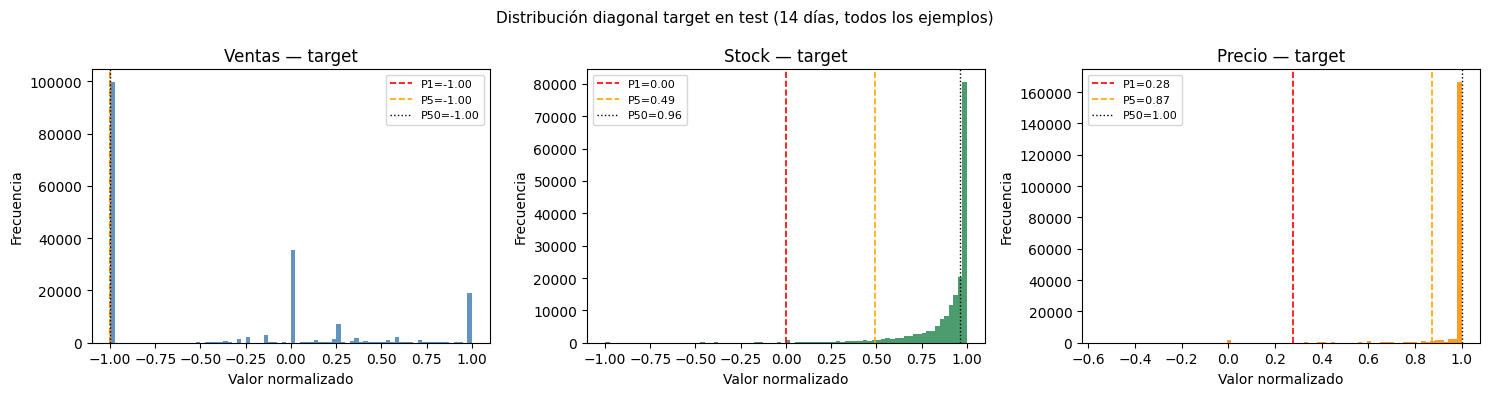

In [14]:
# ── Distribución de valores target por canal ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Distribución diagonal target en test ({FORECAST_HORIZON} días, todos los ejemplos)", fontsize=11)

canal_nombres = ["Ventas", "Stock", "Precio"]
colores_hist  = ["steelblue", "seagreen", "darkorange"]

for c, (ax, nombre, color) in enumerate(zip(axes, canal_nombres, colores_hist)):
    vals = diag_true[:, c, :].flatten()
    ax.hist(vals, bins=80, color=color, edgecolor="none", alpha=0.85)
    ax.set_title(f"{nombre} — target")
    ax.set_xlabel("Valor normalizado")
    ax.set_ylabel("Frecuencia")
    p1  = np.percentile(vals, 1)
    p5  = np.percentile(vals, 5)
    p50 = np.percentile(vals, 50)
    ax.axvline(p1,  color="red",   lw=1.2, linestyle="--", label=f"P1={p1:.2f}")
    ax.axvline(p5,  color="orange",lw=1.2, linestyle="--", label=f"P5={p5:.2f}")
    ax.axvline(p50, color="black", lw=1,   linestyle=":",  label=f"P50={p50:.2f}")
    ax.legend(fontsize=8)
    print(f"{nombre}: min={vals.min():.3f}  P1={p1:.3f}  P5={p5:.3f}  "
          f"P50={p50:.3f}  max={vals.max():.3f}  "
          f"frac<-0.8: {(vals < -0.8).mean():.4f}")

plt.tight_layout()
plt.savefig("/app/outputs/visualizations/test_dist_target_canal.png", dpi=120, bbox_inches="tight")
plt.show()

In [15]:
# ── Barrer umbrales solo para canales con quiebres reales ─────────────────────
# Un canal tiene quiebres detectables si existe algún umbral donde
# n_positivos_reales > 0. Lo verificamos antes de calcular F1.

umbrales = np.linspace(-1.0, 1.0, 200)
resultados = {}
canales_con_quiebres = []

for c_idx, c_nombre in enumerate(["Ventas", "Stock"]):
    diag_t = diag_true[:, c_idx, :]  # (N, 7)
    diag_p = diag_pred[:, c_idx, :]  # (N, 7)

    # Verificar si hay quiebres reales en algún umbral
    max_positivos = max((diag_t < u).any(axis=1).sum() for u in umbrales)
    print(f"{c_nombre}: máximo de muestras con quiebre real en cualquier umbral = {max_positivos:,}")

    if max_positivos == 0:
        print(f"  → Sin quiebres reales de {c_nombre} en test. Se omite el análisis de umbral.\n")
        continue

    canales_con_quiebres.append((c_idx, c_nombre))
    metricas = []
    for u in umbrales:
        real_q = (diag_t < u).any(axis=1)
        pred_q = (diag_p < u).any(axis=1)

        tp = int(( real_q &  pred_q).sum())
        fp = int((~real_q &  pred_q).sum())
        fn = int(( real_q & ~pred_q).sum())
        tn = int((~real_q & ~pred_q).sum())

        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        f1   = 2 * prec * rec / (prec + rec + 1e-9)

        metricas.append({
            "umbral": u, "precision": prec, "recall": rec, "f1": f1,
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "n_real_q": int(real_q.sum()),
        })

    resultados[c_nombre] = metricas
    best = max(metricas, key=lambda x: x["f1"])
    print(f"  Umbral óptimo (F1 max): {best['umbral']:.3f}")
    print(f"  F1={best['f1']:.3f}  Precisión={best['precision']:.3f}  Recall={best['recall']:.3f}")
    print(f"  TP={best['tp']:,}  FP={best['fp']:,}  FN={best['fn']:,}  TN={best['tn']:,}\n")

Ventas: máximo de muestras con quiebre real en cualquier umbral = 13,224
  Umbral óptimo (F1 max): 0.437
  F1=1.000  Precisión=1.000  Recall=1.000
  TP=13,224  FP=0  FN=0  TN=0

Stock: máximo de muestras con quiebre real en cualquier umbral = 11,286
  Umbral óptimo (F1 max): 1.000
  F1=0.921  Precisión=0.853  Recall=1.000
  TP=11,286  FP=1,938  FN=0  TN=0



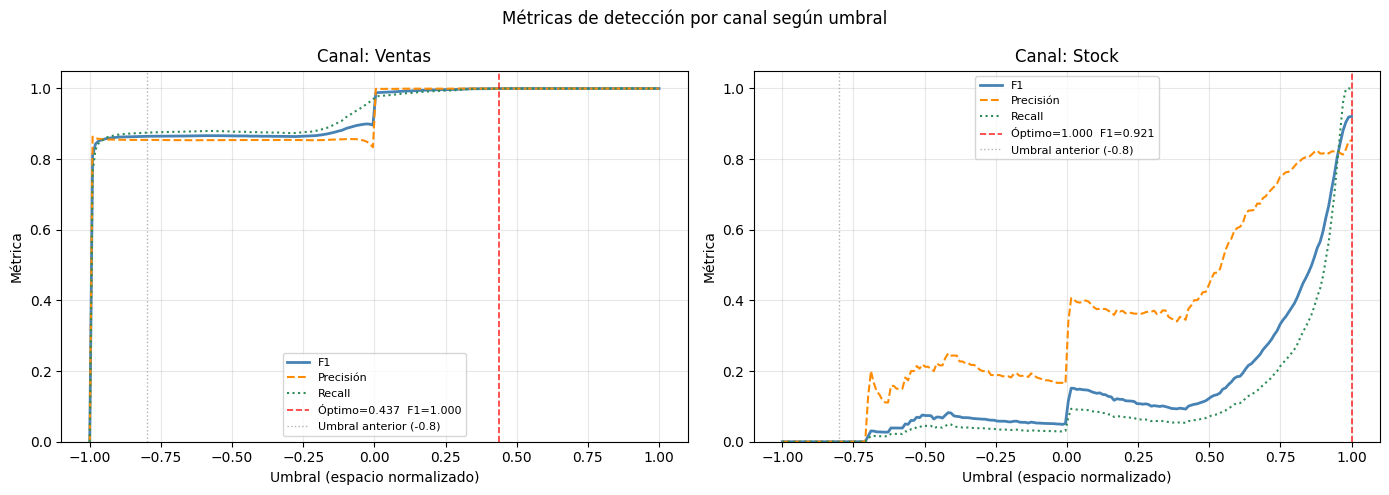

In [16]:
# ── Curvas F1 / Precisión / Recall para canales con quiebres ─────────────────
if not resultados:
    print("Ningún canal tiene quiebres reales en test con los umbrales evaluados.")
else:
    n_plots = len(resultados)
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    fig.suptitle("Métricas de detección por canal según umbral", fontsize=12)

    for ax, (c_nombre, metricas) in zip(axes, resultados.items()):
        umb  = [m["umbral"]    for m in metricas]
        f1s  = [m["f1"]        for m in metricas]
        prec = [m["precision"] for m in metricas]
        rec  = [m["recall"]    for m in metricas]

        ax.plot(umb, f1s,  label="F1",        color="steelblue",  lw=2)
        ax.plot(umb, prec, label="Precisión", color="darkorange", lw=1.5, linestyle="--")
        ax.plot(umb, rec,  label="Recall",    color="seagreen",   lw=1.5, linestyle=":")

        best = max(metricas, key=lambda x: x["f1"])
        ax.axvline(best["umbral"], color="red", lw=1.2, linestyle="--", alpha=0.8,
                   label=f"Óptimo={best['umbral']:.3f}  F1={best['f1']:.3f}")
        ax.axvline(-0.8, color="gray", lw=1, linestyle=":", alpha=0.6,
                   label="Umbral anterior (-0.8)")

        ax.set_title(f"Canal: {c_nombre}")
        ax.set_xlabel("Umbral (espacio normalizado)")
        ax.set_ylabel("Métrica")
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("/app/outputs/visualizations/test_umbral_por_canal.png", dpi=120, bbox_inches="tight")
    plt.show()

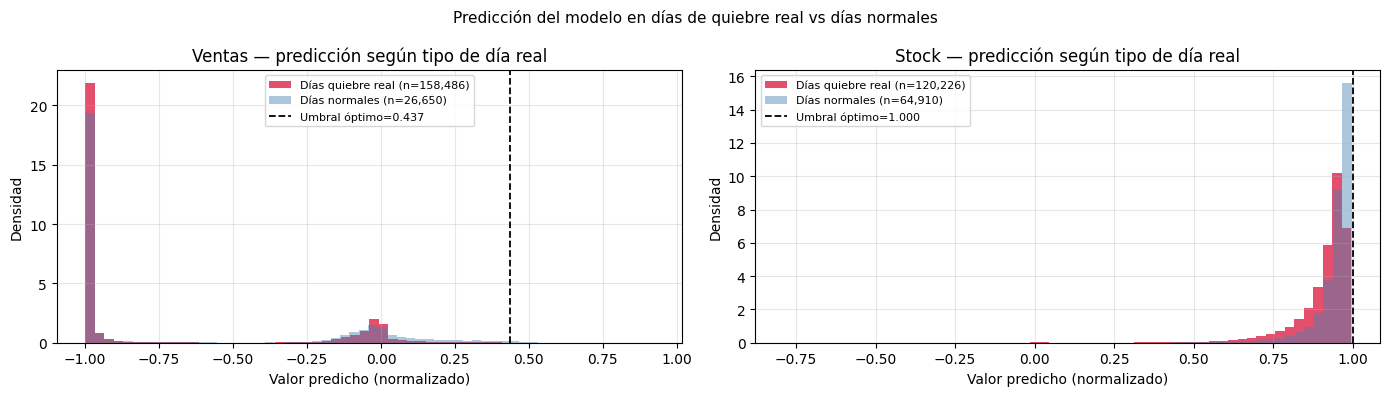

In [17]:
# ── Distribución predicciones en días de quiebre vs normales ─────────────────
if not resultados:
    print("Sin canales con quiebres para analizar.")
else:
    n_plots = len(resultados)
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]
    fig.suptitle("Predicción del modelo en días de quiebre real vs días normales", fontsize=11)

    canal_idx_map = {"Ventas": 0, "Stock": 1}
    for ax, c_nombre in zip(axes, resultados.keys()):
        c_idx = canal_idx_map[c_nombre]
        u_opt = max(resultados[c_nombre], key=lambda x: x["f1"])["umbral"]

        diag_t = diag_true[:, c_idx, :].flatten()
        diag_p = diag_pred[:, c_idx, :].flatten()

        mask_q = diag_t < u_opt
        mask_n = ~mask_q

        ax.hist(diag_p[mask_q], bins=60, alpha=0.75, color="crimson",
                label=f"Días quiebre real (n={mask_q.sum():,})", density=True)
        ax.hist(diag_p[mask_n], bins=60, alpha=0.45, color="steelblue",
                label=f"Días normales (n={mask_n.sum():,})",     density=True)
        ax.axvline(u_opt, color="black", lw=1.3, linestyle="--",
                   label=f"Umbral óptimo={u_opt:.3f}")
        ax.set_title(f"{c_nombre} — predicción según tipo de día real")
        ax.set_xlabel("Valor predicho (normalizado)")
        ax.set_ylabel("Densidad")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("/app/outputs/visualizations/test_pred_dist_por_dia.png", dpi=120, bbox_inches="tight")
    plt.show()

Ventas (log1p norm):
  Media predicha  — Normal: -0.576  Quiebre: -0.771  Δ=+0.195
  Mínimo predicho — Normal: -0.680  Quiebre: -0.881  Δ=+0.200
Stock (log1p norm):
  Media predicha  — Normal: 0.918  Quiebre: 0.841  Δ=+0.077
  Mínimo predicho — Normal: 0.880  Quiebre: 0.690  Δ=+0.190
Precio (norm):
  Media predicha  — Normal: 0.996  Quiebre: nan  Δ=+nan
  Mínimo predicho — Normal: 0.993  Quiebre: nan  Δ=+nan


/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


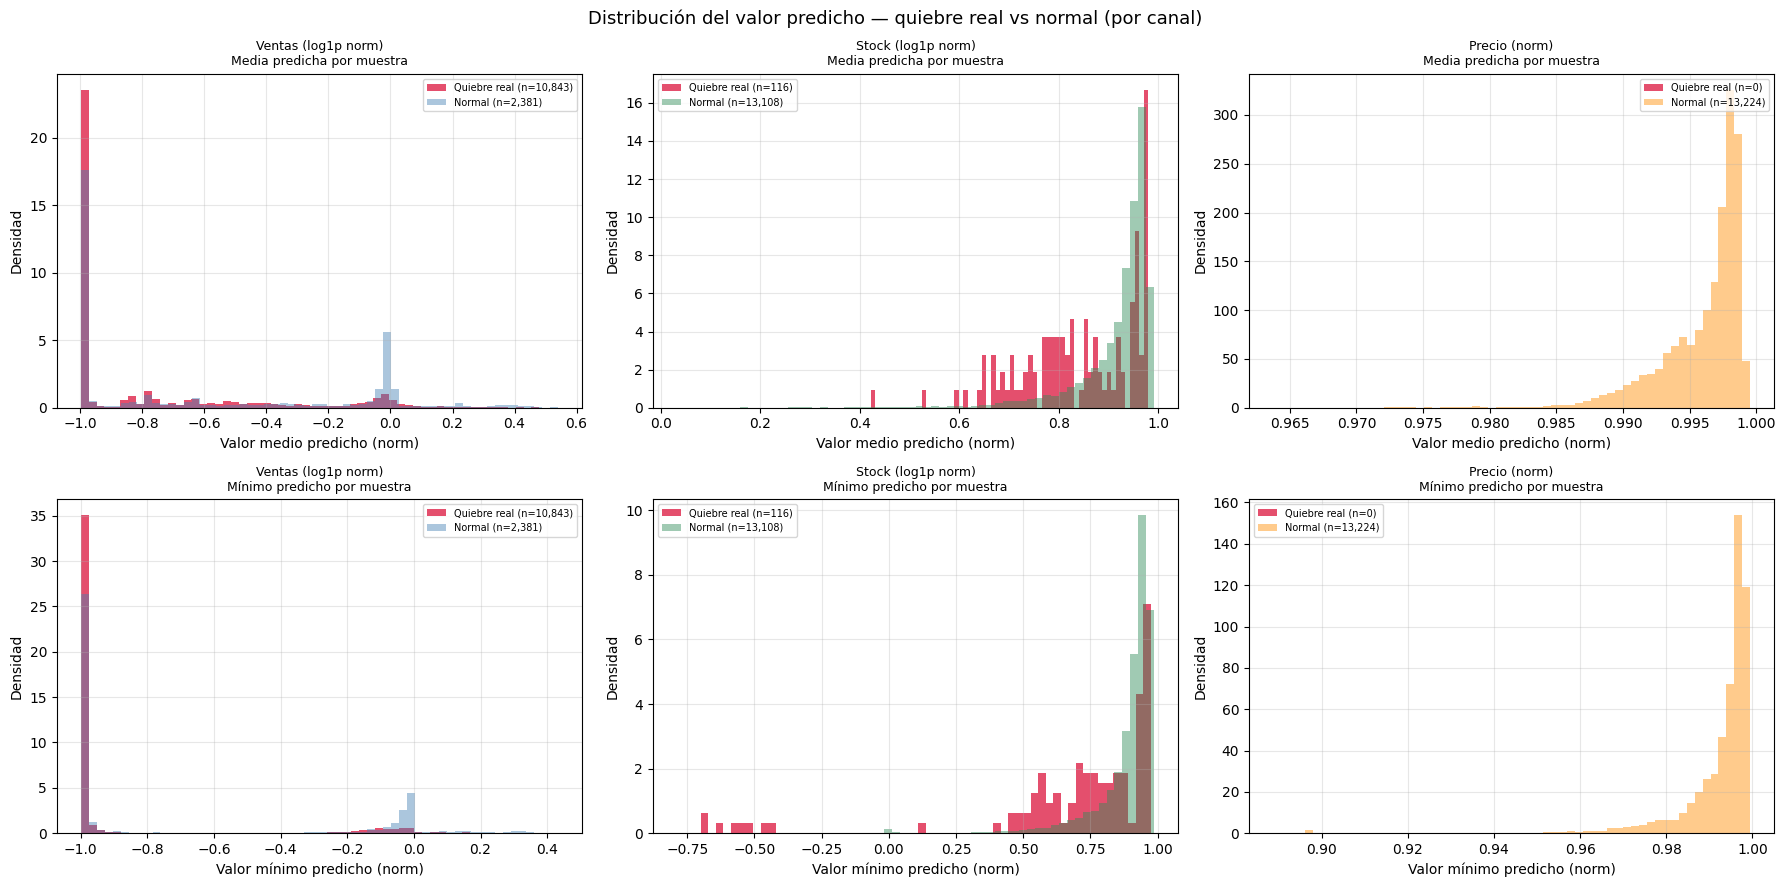

In [18]:
# Distribución del error de predicción por canal — quiebre vs normal
# Ground truth fijo por canal
real_quiebre_ventas = (diag_true[:, 0, :] < -0.99).any(axis=1)
real_quiebre_stock  = (diag_true[:, 1, :] < -0.99).any(axis=1)
real_quiebre_precio = (diag_true[:, 2, :] < -0.99).any(axis=1)

mascaras_real = [real_quiebre_ventas, real_quiebre_stock, real_quiebre_precio]
canal_nombres = ["Ventas (log1p norm)", "Stock (log1p norm)", "Precio (norm)"]
colores_q     = ["crimson", "crimson", "crimson"]
colores_n     = ["steelblue", "seagreen", "darkorange"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle("Distribución del valor predicho — quiebre real vs normal (por canal)", fontsize=13)

for c, (ax_med, ax_min, mask_real, nombre, cq, cn) in enumerate(
    zip(axes[0], axes[1], mascaras_real, canal_nombres, colores_q, colores_n)
):
    n_q = mask_real.sum()
    n_n = (~mask_real).sum()

    # Fila 0: valor medio predicho por muestra
    med_pred = diag_pred[:, c, :].mean(axis=1)
    ax_med.hist(med_pred[mask_real],  bins=60, alpha=0.75, color=cq, density=True,
                label=f"Quiebre real (n={n_q:,})")
    ax_med.hist(med_pred[~mask_real], bins=60, alpha=0.45, color=cn, density=True,
                label=f"Normal (n={n_n:,})")
    ax_med.set_title(f"{nombre}\nMedia predicha por muestra", fontsize=9)
    ax_med.set_xlabel("Valor medio predicho (norm)")
    ax_med.set_ylabel("Densidad")
    ax_med.legend(fontsize=7)
    ax_med.grid(alpha=0.3)

    # Fila 1: valor mínimo predicho por muestra
    min_pred = diag_pred[:, c, :].min(axis=1)
    ax_min.hist(min_pred[mask_real],  bins=60, alpha=0.75, color=cq, density=True,
                label=f"Quiebre real (n={n_q:,})")
    ax_min.hist(min_pred[~mask_real], bins=60, alpha=0.45, color=cn, density=True,
                label=f"Normal (n={n_n:,})")
    ax_min.set_title(f"{nombre}\nMínimo predicho por muestra", fontsize=9)
    ax_min.set_xlabel("Valor mínimo predicho (norm)")
    ax_min.set_ylabel("Densidad")
    ax_min.legend(fontsize=7)
    ax_min.grid(alpha=0.3)

    # Imprimir separación entre distribuciones
    sep_med = med_pred[~mask_real].mean() - med_pred[mask_real].mean()
    sep_min = min_pred[~mask_real].mean() - min_pred[mask_real].mean()
    print(f"{nombre}:")
    print(f"  Media predicha  — Normal: {med_pred[~mask_real].mean():.3f}  "
          f"Quiebre: {med_pred[mask_real].mean():.3f}  Δ={sep_med:+.3f}")
    print(f"  Mínimo predicho — Normal: {min_pred[~mask_real].mean():.3f}  "
          f"Quiebre: {min_pred[mask_real].mean():.3f}  Δ={sep_min:+.3f}")

plt.tight_layout()
plt.savefig("/app/outputs/visualizations/test_dist_pred_por_canal.png", dpi=120, bbox_inches="tight")
plt.show()

In [19]:
# ── Resumen ejecutivo ─────────────────────────────────────────────────────────
print("═" * 60)
print("  RESUMEN — UMBRAL ÓPTIMO POR CANAL")
print("═" * 60)

for c_nombre, metricas in resultados.items():
    best   = max(metricas, key=lambda x: x["f1"])
    # Buscar el umbral más cercano a -0.8 en la grilla
    actual = min(metricas, key=lambda m: abs(m["umbral"] - (-0.8)))
    mejora = best["f1"] - actual["f1"]

    print(f"\n  {c_nombre}:")
    print(f"    Umbral actual  ({actual['umbral']:+.3f}) → "
          f"F1={actual['f1']:.3f}  Prec={actual['precision']:.3f}  Rec={actual['recall']:.3f}")
    print(f"    Umbral óptimo ({best['umbral']:+.3f}) → "
          f"F1={best['f1']:.3f}  Prec={best['precision']:.3f}  Rec={best['recall']:.3f}")
    print(f"    Mejora F1: {mejora:+.3f}")

# Canales omitidos
omitidos = [n for n in ["Ventas", "Stock"] if n not in resultados]
if omitidos:
    print(f"\n  Canales sin quiebres reales en test (omitidos): {', '.join(omitidos)}")
    print(f"  → El F1 global viene exclusivamente de: "
          f"{', '.join(resultados.keys())}")

print()
print("  Interpretación:")
print("  - Umbral óptimo cercano a 0.0 en ventas → el modelo predice")
print("    quiebre cuando las ventas bajan, no solo cuando llegan a cero.")
print("  - Si stock no tiene quiebres en test → el período de test")
print("    no contiene semanas con stockout real de stock.")
print("═" * 60)

════════════════════════════════════════════════════════════
  RESUMEN — UMBRAL ÓPTIMO POR CANAL
════════════════════════════════════════════════════════════

  Ventas:
    Umbral actual  (-0.799) → F1=0.865  Prec=0.854  Rec=0.875
    Umbral óptimo (+0.437) → F1=1.000  Prec=1.000  Rec=1.000
    Mejora F1: +0.135

  Stock:
    Umbral actual  (-0.799) → F1=0.000  Prec=0.000  Rec=0.000
    Umbral óptimo (+1.000) → F1=0.921  Prec=0.853  Rec=1.000
    Mejora F1: +0.921

  Interpretación:
  - Umbral óptimo cercano a 0.0 en ventas → el modelo predice
    quiebre cuando las ventas bajan, no solo cuando llegan a cero.
  - Si stock no tiene quiebres en test → el período de test
    no contiene semanas con stockout real de stock.
════════════════════════════════════════════════════════════
